# A simple causal discovery and inference pipeline using simulated data with known causal influences

## Notebook outline

The notebook runs through the following:

1. Package installs
2. Create synthetic data with known causal relationships
3. Identify a DAG using Peter-Clarke algorithm
4. Adjust required P value
5. Using the kernal method (best but very slow)
6. Add knowledge (required or forbidden edges)

---

## 1. Package installs

Standard packages use are numpy, pandas, matplotlib, scikit-learn

For specialist packages, run the following code cell (currently commented out):

In [1]:
# !pip install causallearn dowhy econml networkx pydot graphviz

In [2]:
# Import general packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydot
import networkx as nx
from networkx.algorithms.d_separation import is_d_separator

# Import causal-learn packages for causal discovery
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge

# Import Causal Forest packages for causal inference (conditional average treatment effecs)
from dowhy import CausalModel
from econml.grf import CausalForest
from econml.dml import CausalForestDML # Causal forest with double machine learning
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

---

## 2 Create synthetic data with known causal relationships

Data is simulated to mimic stroke patients, treatment, and outcomes

* *Patient characteristics*: age, ethnicity, sex, use of warfarin, stroke severity, shoe size
* *Outcome*: death
* *Treatment*: thrombolysis (a clot-busting treatment aimed at dissolving the clot causing the stroke)

### Rules for synthetic data

Synthetic data based on:

POPULATION:

* Patients are aged 60-95, uniformly distrIbuted
* Ethnicity is 70% white, 20% asian, 10% black
* Patients are split 50:50 male:female
* Stroke severity (NIHSS) has triangular distrubution ranging from 0 to 30
* Shoe_size is set to add noise to data (they have no effect)

MORTALITY:

* Baseline mortality is 10%
* Mortality increases by 1 percentage point every year above age 60
* Mortality increases 10 percentage points for males
* Morrtality increases 1 percentage points for each NIHSS unit

THROMBOLYSIS USE:

* Baseline thrombolysis treatment is 20%
* Thrombolysis rate is reduced 5% for asian patients and 10% for black patients
* Thrombolysis rate is halved if aged more than 80
* No thrombolysis use for NIHSS <5; thrombolysis use declines to zero between NIHSS 20 and 30
* Warfarin reduces thrombolysis use by 90%

THROMBOLYSIS EFFICACY

* The baseline effect of use of thrombolysis is to halve mortality
* Thrombolysis is half as effective in asian and black people
* Thrombolysis is half as effective if aged 80%
* The effectiveness climbs between NIHSS 5 and 10, is stable NIHSS 10-20 and declines to zero between 20 and 30.

In [3]:
np.random.seed(42)
N = 5_000

# ──── Make synthetic data ────

# --- Demographics
age = np.random.randint(60, 96, size=N)
ethnicity = np.random.choice(['white', 'asian', 'black'], size=N, p=[0.70, 0.20, 0.10])
male = np.random.randint(0, 2, size=N)

# --- Warfarin (20% prevalence) ---
warfarin = np.random.binomial(1, 0.20, size=N)

# --- Noise variables (no causal role) ---
shoe_size = np.random.triangular(5, 9, 13, size=N).astype(int)

# --- NIHSS stroke severity (triangular distribution, 0–30, mode 10) ---
nihss = np.random.triangular(0, 10, 30, size=N).astype(int)

# NIHSS determines:
#   - eligibility/probability of thrombolysis (zero below 5, ramps 5-10, 
#   - stable 10-20, ramps down 20-30)
#   - effectiveness of thrombolysis (same shape)
#   - baseline mortality risk (linear increase with severity)

def nihss_weight(n):
    """Returns a 0–1 weight encoding the NIHSS-driven treatment/effect profile."""
    if n < 5:
        return 0.0
    elif n < 10:
        return (n - 5) / 5.0
    elif n <= 20:
        return 1.0
    elif n <= 30:
        return (30 - n) / 10.0
    else:
        return 0.0

nihss_wt = np.array([nihss_weight(n) for n in nihss])

# --- Thrombolysis probability ---
thrombolysis_prob = np.full(N, 0.20)
thrombolysis_prob[ethnicity == 'asian'] -= 0.05
thrombolysis_prob[ethnicity == 'black'] -= 0.10
thrombolysis_prob[age > 80] /= 2
thrombolysis_prob[warfarin == 1] *= 0.10
thrombolysis_prob *= nihss_wt
thrombolysis_prob = np.clip(thrombolysis_prob, 0, 1)

thrombolysis = np.random.binomial(1, thrombolysis_prob)

# --- Mortality probability ---
mortality_prob = np.full(N, 0.10)
mortality_prob += (age - 60) * 0.01
mortality_prob[male == 1] += 0.10
mortality_prob += nihss * 0.01
mortality_prob = np.clip(mortality_prob, 0, 1)

# --- Thrombolysis effect on mortality ---
# Demographic modifiers (same as v1):
#   - Both age>80 AND non-white: multiplier 0.875 (reduction halved twice)
#   - Either alone:              multiplier 0.75  (reduction halved once)
#   - Neither:                   multiplier 0.5   (full 50% reduction)
# NIHSS scales the reduction: multiplier = 1 - (1 - base_mult) * nihss_wt
# When nihss_wt=0 → no effect; nihss_wt=1 → full demographic-adjusted effect
reduced_effectiveness = (ethnicity == "asian") | (ethnicity == "black")
age_over_80_treated = (thrombolysis == 1) & (age > 80)
ethnicity_reduced   = (thrombolysis == 1) & reduced_effectiveness
both = age_over_80_treated & ethnicity_reduced

base_multiplier = np.where(both, 0.875,
    np.where(age_over_80_treated | ethnicity_reduced, 0.75, 0.5))

nihss_scaled_multiplier = 1.0 - (1.0 - base_multiplier) * nihss_wt
thrombolysis_effect = np.where(thrombolysis == 0, 1.0, nihss_scaled_multiplier)

mortality_prob *= thrombolysis_effect
mortality_prob = np.clip(mortality_prob, 0, 1)

died = np.random.binomial(1, mortality_prob)

# --- DataFrame ---
df = pd.DataFrame({
    "patient_id":         np.arange(1, N + 1),
    "age":                age,
    "ethnicity":          ethnicity,
    "male":               male,
    "warfarin":           warfarin,
    "shoe_size":          shoe_size,
    "nihss":              nihss,
    "thrombolysis_prob":  np.round(thrombolysis_prob, 4),
    "thrombolysis":       thrombolysis,
    "mortality_prob":     np.round(mortality_prob, 4),
    "died":               died,
})

# ──── Compute TRUE treatment effects from data-generating process ────

# Reconstruct potential outcome under treatment for every patient
mortality_base = np.full(N, 0.10)
mortality_base += (df["age"].values - 60) * 0.01
mortality_base[df["ethnicity"] == "asian"] += 0.05
mortality_base[df["ethnicity"] == "black"] += 0.10
mortality_base[df["male"] == 1] += 0.10
mortality_base += df["nihss"].values * 0.01
mortality_base = np.clip(mortality_base, 0, 1)

nihss_wt_all = np.array([nihss_weight(n) for n in df["nihss"].values])
reduced_eff_all = (df["ethnicity"] == "asian") | (df["ethnicity"] == "black")
age_over_80_all = df["age"].values > 80
both_all        = age_over_80_all & reduced_eff_all.values

base_mult_all = np.where(both_all, 0.875,
    np.where(age_over_80_all | reduced_eff_all.values, 0.75, 0.5))

true_tx_multiplier = 1.0 - (1.0 - base_mult_all) * nihss_wt_all
mortality_treated  = np.clip(mortality_base * true_tx_multiplier, 0, 1)

# True CATE = E[Y(1)] – E[Y(0)]; negative = treatment reduces mortality
true_cate = mortality_treated - mortality_base
df["true_cate"] = np.round(true_cate, 6)

# ──── Save (if necessary)────
#df.to_csv("synthetic_stroke_data.csv", index=False)
#print("Saved synthetic_stroke_data.csv:", df.shape)

---

## 2. Identify causal relationships using causallearn.search.ConstraintBased.PC

The `causallearn.search.ConstraintBased.PC` function is an implementation of the Peter-Clark (PC) algorithm in the `causal-learn` Python library. As a constraint-based causal discovery method, the PC algorithm uses conditional independence tests on observational data to identify causal relationships, returning a Directed Acyclic Graph (DAG) or Partially Directed Acyclic Graph (CPDAG). [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

The algorithm systematically prunes a fully connected network into a sparse graph based on statistical evidence, assuming there are no unmeasured (latent) confounders. [lmyint.github](https://lmyint.github.io/causal_spring_2020/causal-discovery.html)

### 1. Skeleton Discovery (Adjacency Search)
The PC algorithm begins with a fully connected graph containing all observed variables. It iteratively removes edges by testing for conditional independence. First, it tests all pairs of variables for marginal (unconditional) independence, removing edges where no association is found. It then tests remaining adjacent variables for conditional independence given subsets of size 1, then size 2, increasing the subset size systematically. If $X$ and $Y$ are found to be conditionally independent given a subset $Z$, the edge between them is deleted, and $Z$ is recorded as the "separation set" (sepset) for that pair. [jmlr](https://jmlr.org/papers/volume15/colombo14a/colombo14a.pdf)

### 2. Collider Orientation (v-structures)
Once the skeleton is finalized, the algorithm looks for unshielded triples—patterns where variable $X$ is connected to $Y$, and $Y$ is connected to $Z$, but $X$ and $Z$ are not connected. For each unshielded triple $X - Y - Z$, it checks the sepset recorded when the edge between $X$ and $Z$ was deleted. If $Y$ is *not* in that sepset, the algorithm orients the edges toward $Y$ to form a collider (v-structure): $X \rightarrow Y \leftarrow Z$. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

### 3. Edge Orientation Rules
After identifying all colliders, the algorithm applies a set of logical rules (Meek rules) to orient as many remaining undirected edges as possible without creating new colliders or cycles. For example, if it finds $X \rightarrow Y - Z$ and orienting $Y \leftarrow Z$ would create a new collider that wasn't identified in step 2, it logically forces the orientation $Y \rightarrow Z$. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

### Python Implementation and Parameters
In `causal-learn`, the `pc()` function is called with the dataset (a NumPy array) and allows for several key configurations: [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `alpha`: The significance level for the conditional independence tests (default 0.05). [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `indep_test`: The statistical test used, such as Fisher's Z (`fisherz`) for linear continuous data, Chi-squared for discrete data, or Kernel-based (`kci`) for non-linear continuous data. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `uc_rule` and `uc_priority`: Define how the algorithm handles conflicting unshielded colliders, offering options like maxP (orienting based on additional CI tests) to improve robustness. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `mvpc`: Allows the algorithm to handle missing values natively. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

The function returns a `CausalGraph` object (`cg`), where `cg.G.graph` contains the final adjacency matrix representing the discovered causal relationships. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

  0%|          | 0/8 [00:00<?, ?it/s]

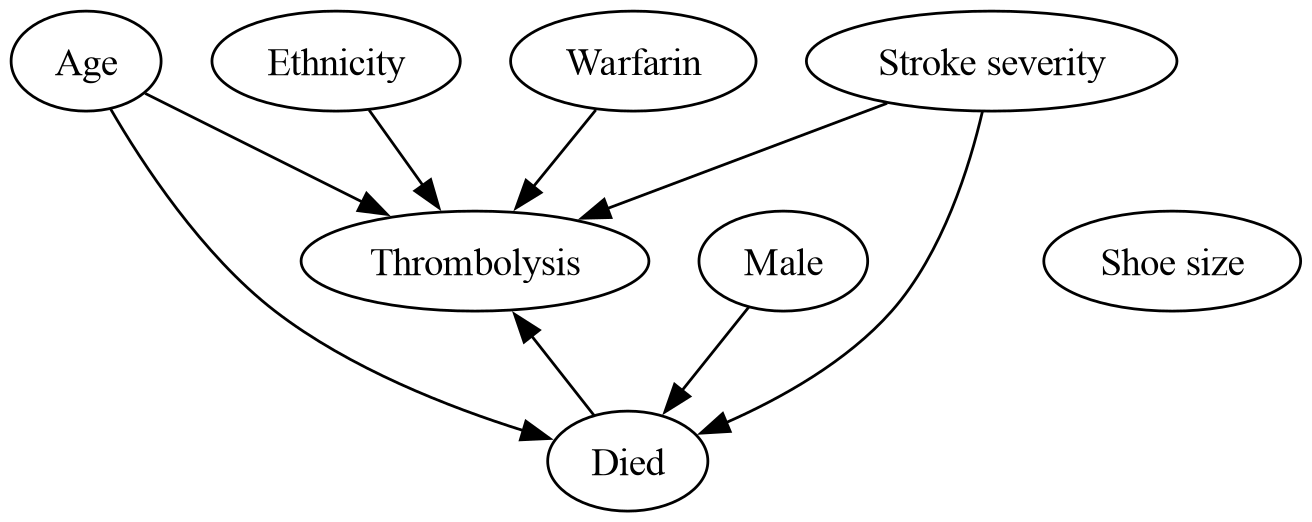

In [4]:
# --- Preprocessing ---
# 1. Map ethnicity to numeric values for the algorithm
ethnicity_map = {'white': 0, 'asian': 1, 'black': 2}
df['ethnicity_idx'] = df['ethnicity'].map(ethnicity_map)

# 2. Select only the features relevant to the causal structure
feature_cols = [
    'age', 'ethnicity_idx', 'male', 'thrombolysis', 'nihss', 'warfarin', 'shoe_size', 'died']
data_for_pc = df[feature_cols].to_numpy()

# Define the labels in the same order as feature_cols
node_names = [
    'Age', 'Ethnicity', 'Male', 'Thrombolysis', 'Stroke severity', 'Warfarin', 'Shoe size', 'Died']

# Run PC with names, alpha=0.05 is the significance level for independence tests
cg = pc(data_for_pc, alpha=0.05, node_names=node_names)

# --- Visualization using Graphviz ---
# 1. Generate the initial pydot graph
pyd = GraphUtils.to_pydot(cg.G)

# 2. Create a subgraph that forces its contents to the bottom
sink_subgraph = pydot.Subgraph(rank='sink')

# 3. Find the 'died' node and add it to the sink subgraph
for node in pyd.get_nodes():
    if 'Died' in str(node.get_name()) or 'Died' in str(node.get_label()):
        sink_subgraph.add_node(pydot.Node(node.get_name()))
        break

# 4. Add the subgraph back to the main graph
pyd.add_subgraph(sink_subgraph)

# 5. Save the modified graph
#pyd.write_png('./output/stroke_causal_dag.png')

# 6. Display directly in a Jupyter Notebook
from IPython.display import Image
Image(data=pyd.create_png(), width=800)


---
## 4. Adjust required p level

Increasing the statistical significance required reduced the risk of false positive connections, but increases the risk of false negatives.

As P value is reduced (higher strength required), the DAG becomes more sparse.

  0%|          | 0/8 [00:00<?, ?it/s]

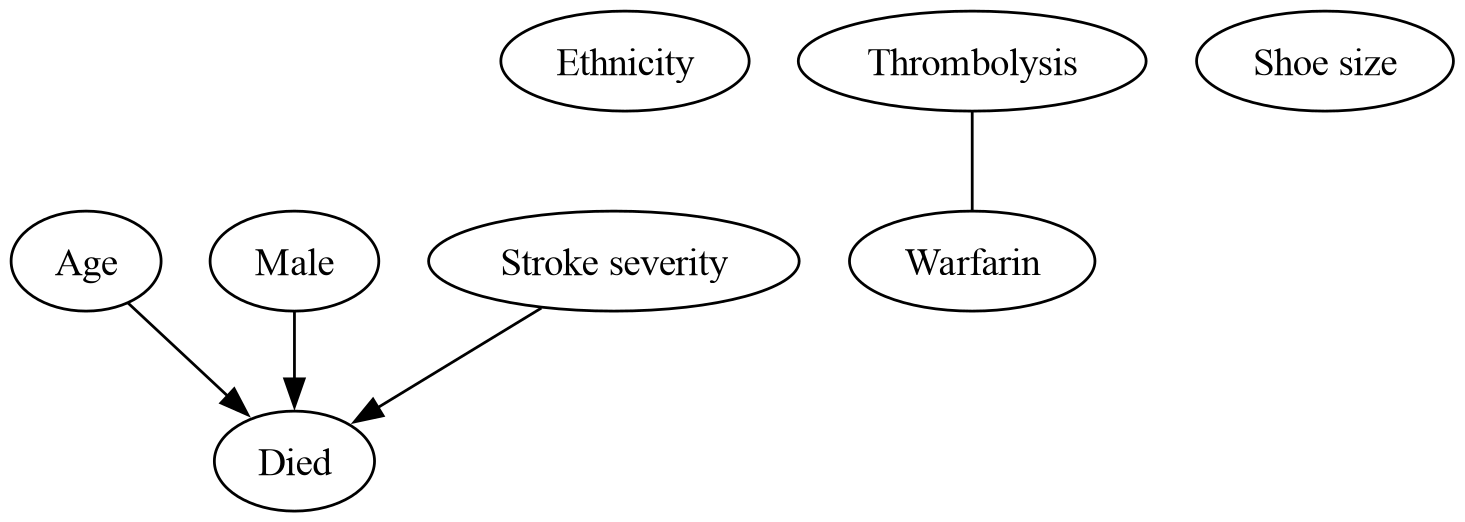

In [5]:
# Delete the previous graph and run with a more stringent alpha to see how the graph changes
del cg
del pyd

# Run PC with names, alpha=1e-9 is the significance level for independence tests
cg = pc(data_for_pc, alpha=1e-9, node_names=node_names)

# --- Visualization using Graphviz ---
# 1. Generate the initial pydot graph
pyd = GraphUtils.to_pydot(cg.G)

# 2. Create a subgraph that forces its contents to the bottom
sink_subgraph = pydot.Subgraph(rank='sink')

# 3. Find the 'died' node and add it to the sink subgraph
for node in pyd.get_nodes():
    if 'Died' in str(node.get_name()) or 'Died' in str(node.get_label()):
        sink_subgraph.add_node(pydot.Node(node.get_name()))
        break

# 4. Add the subgraph back to the main graph
pyd.add_subgraph(sink_subgraph)

# 5. Save the modified graph
#pyd.write_png('./output/stroke_causal_dag.png')

# 6. Display directly in a Jupyter Notebook
from IPython.display import Image
Image(data=pyd.create_png(), width=800)

Low significance required.

As P value increased (lower significance required), the DAG becomes less sparse.

  0%|          | 0/8 [00:00<?, ?it/s]

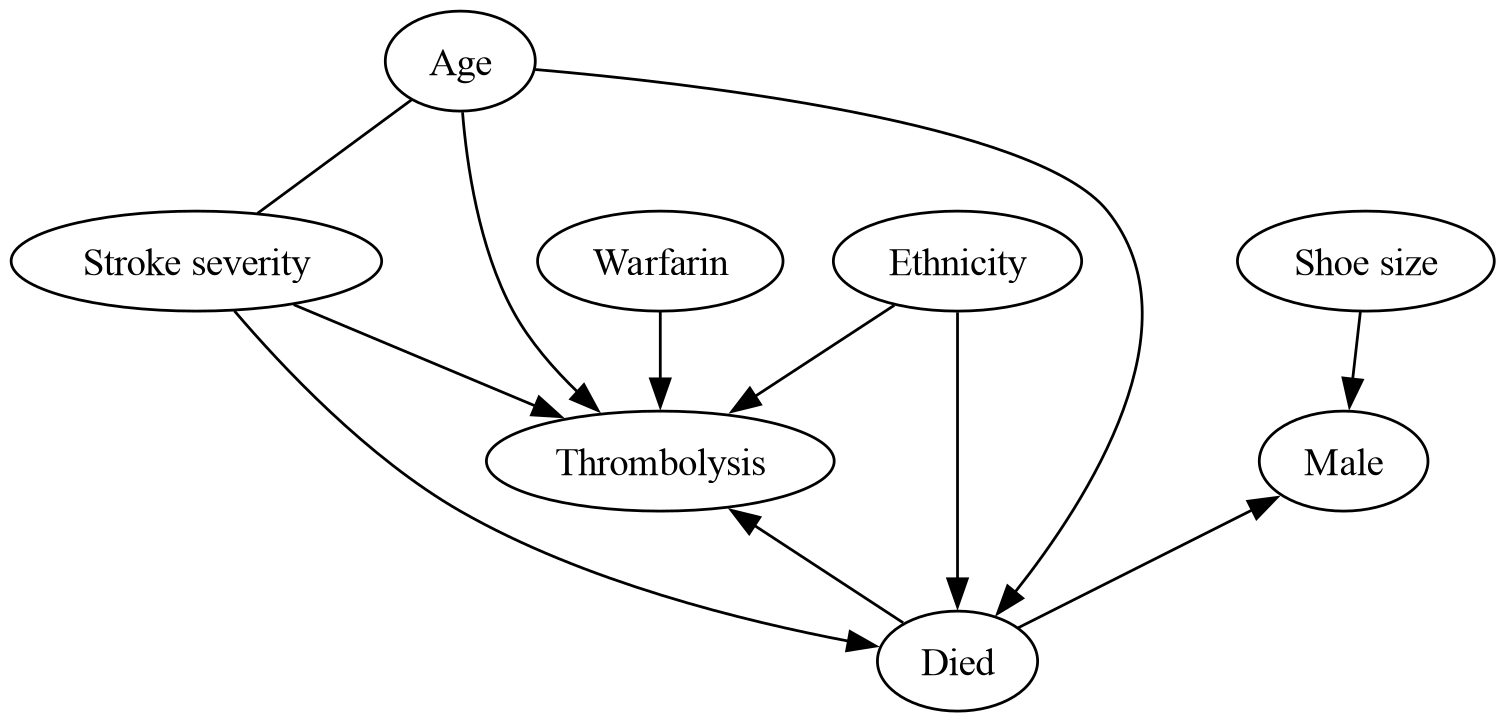

In [6]:
# Delete the previous graph and run with less alpha to see how the graph changes
del cg
del pyd

# Run PC with names, alpha=0.25 is the significance level for independence tests
cg = pc(data_for_pc, alpha=0.25, node_names=node_names)

# --- Visualization using Graphviz ---
# 1. Generate the initial pydot graph
pyd = GraphUtils.to_pydot(cg.G)

# 2. Create a subgraph that forces its contents to the bottom
sink_subgraph = pydot.Subgraph(rank='sink')

# 3. Find the 'died' node and add it to the sink subgraph
for node in pyd.get_nodes():
    if 'Died' in str(node.get_name()) or 'Died' in str(node.get_label()):
        sink_subgraph.add_node(pydot.Node(node.get_name()))
        break

# 4. Add the subgraph back to the main graph
pyd.add_subgraph(sink_subgraph)

# 5. Save the modified graph
#pyd.write_png('./output/stroke_causal_dag.png')

# 6. Display directly in a Jupyter Notebook
from IPython.display import Image
Image(data=pyd.create_png(), width=800)

---

## 5. Kernal based method - best but very slow on large data sets

KCI is theoretically the most powerful for nonlinear relationships but has **O(n³)** complexity, so it's slow on large samples.

  0%|          | 0/8 [00:00<?, ?it/s]

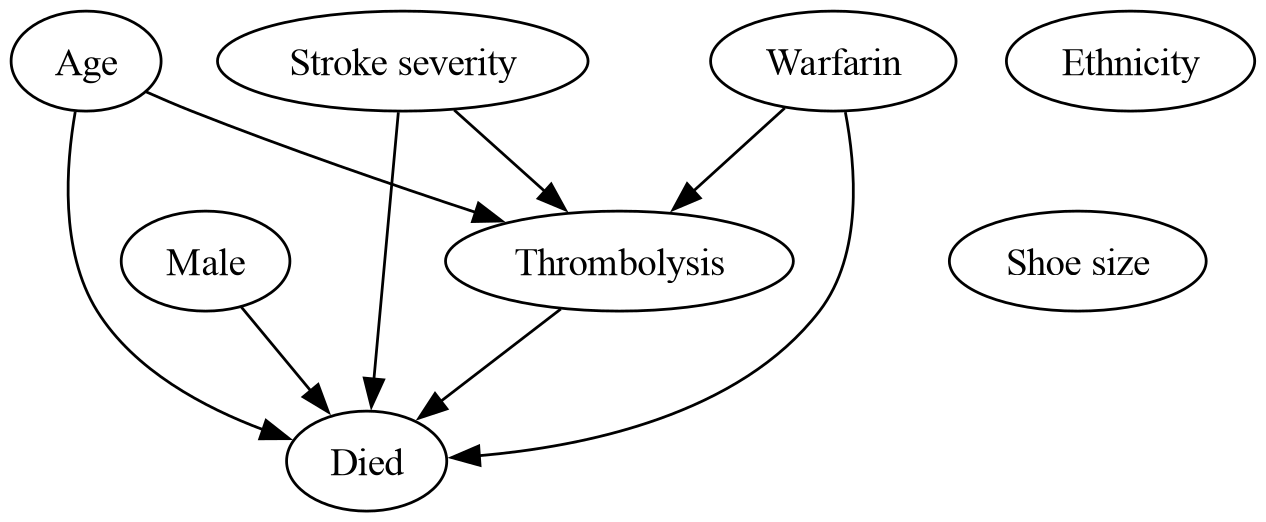

In [7]:
# Sample 2,000 rows to speed up the algorithm for demonstration purposes
sampled_data = df[feature_cols].sample(n=2000, random_state=42).to_numpy()

# Run PC with names, alpha=0.05 is the significance level for independence tests
cg = pc(sampled_data, alpha=0.05, indep_test='kci', node_names=node_names)

# --- Visualization using Graphviz ---
# 1. Generate the initial pydot graph
pyd = GraphUtils.to_pydot(cg.G)

# 2. Create a subgraph that forces its contents to the bottom
sink_subgraph = pydot.Subgraph(rank='sink')

# 3. Find the 'died' node and add it to the sink subgraph
for node in pyd.get_nodes():
    if 'Died' in str(node.get_name()) or 'Died' in str(node.get_label()):
        sink_subgraph.add_node(pydot.Node(node.get_name()))
        break

# 4. Add the subgraph back to the main graph
pyd.add_subgraph(sink_subgraph)

# 5. Save the modified graph
#pyd.write_png('./output/stroke_causal_dag.png')

# 6. Display directly in a Jupyter Notebook
from IPython.display import Image
Image(data=pyd.create_png(), width=800)

---

# 6 Adding knowledge

A simple example:

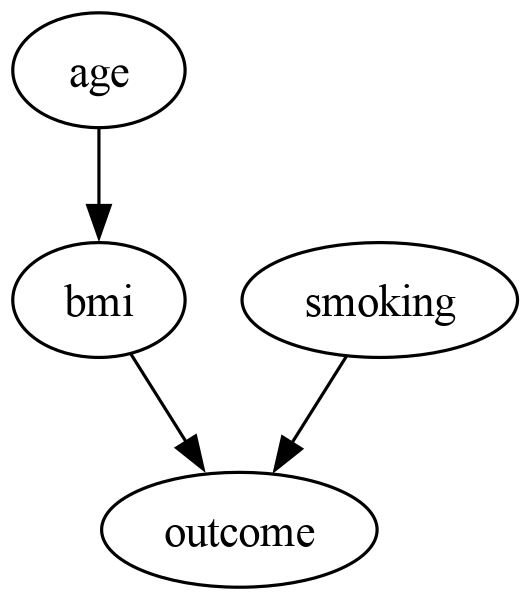

In [8]:
# Simulate some data: age -> bmi -> outcome, smoking -> outcome
np.random.seed(42)
n = 500
age     = np.random.normal(50, 10, n)
smoking = np.random.binomial(1, 0.3, n)
bmi     = 0.1 * age + np.random.normal(0, 1, n)
outcome = 0.5 * bmi + 0.8 * smoking + np.random.normal(0, 1, n)

data = np.column_stack([age, bmi, smoking, outcome])
feature_names = ['age', 'bmi', 'smoking', 'outcome']

# Build named nodes
nodes = {name: GraphNode(name) for name in feature_names}

bk = (
    BackgroundKnowledge()
    .add_required_by_node(nodes['age'],     nodes['bmi'])      # age → bmi (known)
    .add_forbidden_by_node(nodes['outcome'], nodes['age'])     # outcome -X→ age
    .add_forbidden_by_node(nodes['outcome'], nodes['bmi'])     # outcome -X→ bmi
    .add_forbidden_by_node(nodes['outcome'], nodes['smoking']) # outcome -X→ smoking
    .add_forbidden_by_node(nodes['smoking'], nodes['age'])     # smoking -X→ age
)

# --- Step 3: Re-run PC with background knowledge ---
cg_bk = pc(data, alpha=0.05, node_names=feature_names, background_knowledge=bk, show_progress=False)


# Display
pyd_small = GraphUtils.to_pydot(cg_bk.G)
pyd_small.set_size("4,3!")
Image(data=pyd_small.create_png(), width=350)

Using our simulated data.

  0%|          | 0/8 [00:00<?, ?it/s]

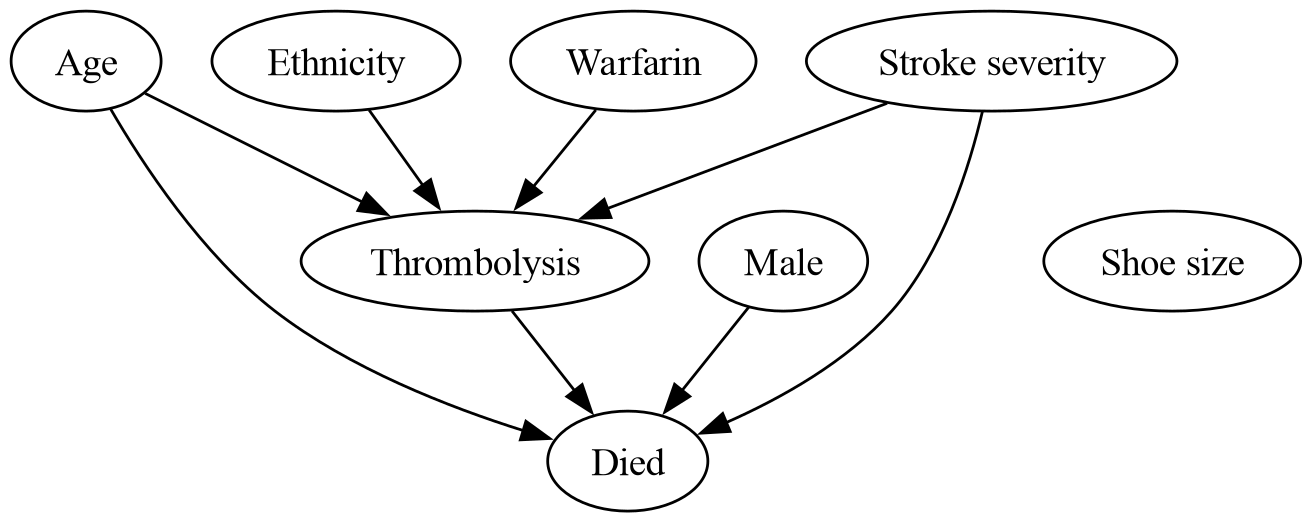

In [9]:
# 1. Map ethnicity to numeric values for the algorithm
ethnicity_map = {'white': 0, 'asian': 1, 'black': 2}
df['ethnicity_idx'] = df['ethnicity'].map(ethnicity_map)

# 2. Select only the features relevant to the causal structure
feature_cols = [
    'age', 'ethnicity_idx', 'male', 'thrombolysis', 'nihss', 'warfarin', 'shoe_size', 'died']
data_for_pc = df[feature_cols].to_numpy()

# Define the labels in the same order as feature_cols
node_names = [
    'Age', 'Ethnicity', 'Male', 'Thrombolysis', 'Stroke severity', 'Warfarin', 'Shoe size', 'Died']

# Build named nodes
nodes = {name: GraphNode(name) for name in feature_names}

# Add background knowledge

# Rebuild nodes for this graph (matching feature_cols/node_names)
nodes = {col: GraphNode(name) for col, name in zip(feature_cols, node_names)}

# Add background knowledge: Died cannot cause any other variable
bk = BackgroundKnowledge()
# Avoid adding forbidden edges from "died"
for col in feature_cols:
    if col != "died":
        bk.add_forbidden_by_node(nodes["died"], nodes[col])
# Forbid shoe_size → age (shoe size can't cause age)
bk.add_forbidden_by_node(nodes["shoe_size"], nodes["age"])
# Require warfarin → thrombolysis (warfarin is a strong contraindication for thrombolysis)
bk.add_required_by_node(nodes["warfarin"], nodes["thrombolysis"])

# Run PC with names, alpha=0.05 is the significance level for independence tests
cg = pc(data_for_pc, alpha=0.05, node_names=node_names, background_knowledge=bk)

# --- Visualization using Graphviz ---
# 1. Generate the initial pydot graph
pyd = GraphUtils.to_pydot(cg.G)

# 2. Create a subgraph that forces its contents to the bottom
sink_subgraph = pydot.Subgraph(rank='sink')

# 3. Find the 'died' node and add it to the sink subgraph
for node in pyd.get_nodes():
    if 'Died' in str(node.get_name()) or 'Died' in str(node.get_label()):
        sink_subgraph.add_node(pydot.Node(node.get_name()))
        break

# 4. Add the subgraph back to the main graph
pyd.add_subgraph(sink_subgraph)

# 5. Save the modified graph
#pyd.write_png('./output/stroke_causal_dag.png')

# 6. Display directly in a Jupyter Notebook
from IPython.display import Image
Image(data=pyd.create_png(), width=800)